In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import torch, torch.nn as nn, torch.optim as optim
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
project_root = Path.cwd().resolve().parents[1]
sys.path.append(str(project_root))

from defs.vae.ae import *
from defs.vae.training_defs import *
from defs.training_defs.loss import *

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

spectra, fractions = load_spectral_data()
train_loader, val_loader = get_dataloaders(spectra, fractions, batch_size=1)
# unbatched_data = get_dataloader_unbatched(spectra, fractions)
num_spectra = train_loader.dataset[0][0].size(0)
print(train_loader.batch_size)
print(num_spectra)

Device: cpu
1
210


In [4]:
convolution = ConvEncoder([train_loader.batch_size, 64, 64], [256, 256], c_d={'pad': 1}, num_spectra=num_spectra)

ratio = 1 # Coefficient of spectral angle mapper (SAM) loss
criterion = loss_mse_sam(ratio=ratio)

learning_rate = 1e-3
optimizer = optim.Adam(convolution.parameters(), lr=learning_rate)

n_epochs = 10

In [5]:
train_losses = []
val_losses = []

for epoch in range(1, n_epochs+1):
    #Training loop
    convolution.train()
    tot_loss = 0
    for xb, yb in train_loader:
        xb = xb.to(device)
        optimizer.zero_grad()
        loss_pred = criterion.calc(convolution(xb), xb)
        loss_pred.backward()
        optimizer.step()

        tot_loss += float(loss_pred)

    train_losses.append(tot_loss / len(train_loader.dataset))

    convolution.eval()
    tot_val = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            tot_val += criterion.calc(convolution(xb), xb).item() * xb.size(0)
    val_losses.append(tot_val / len(val_loader.dataset))

/Users/galacticmilk/Desktop/Michael's folder/[UNI]/[UTAT]/[science]/FINCH-Science_SyntheticData/defs/training_defs/loss.py:29: UserWarning: Using a target size (torch.Size([210])) that is different to the input size (torch.Size([1, 210])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_mse = F.mse_loss(x0_hat, x0)


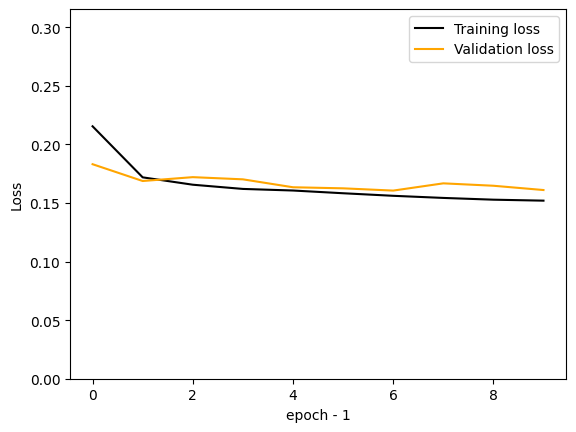

In [6]:
plt.plot(train_losses, color='black', label='Training loss')
plt.plot(val_losses, color='orange', label='Validation loss')
plt.ylim(0, max(max(train_losses), max(val_losses)) + 0.1)
plt.xlabel('epoch - 1'); plt.ylabel('Loss'); plt.legend()

In [7]:
print(f'Final training Loss: {train_losses[-1]:.5f}')
print(f'Final validation Loss: {val_losses[-1]:.5f}')

Final training Loss: 0.15196
Final validation Loss: 0.16103
